In [1]:
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold
from transformers import RobertaTokenizer, RobertaModel
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import time
import random, numpy as np
from torch.optim import AdamW
from tqdm.auto import tqdm
import os
import gc
from torch.cuda.amp import GradScaler
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import shap



import warnings
warnings.filterwarnings("ignore")  # Suppress all Python warnings

2025-09-05 21:37:46.837068: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757108266.861054    9759 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757108266.868163    9759 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
print(f"Available GPUs: {torch.cuda.device_count()}")


Available GPUs: 2


In [ ]:
# Load CSV dataset
df = pd.read_csv("/kaggle/input/PURE_REQ.csv", sep=";")

# We're focusing only on binary classification (F vs. NFR)
df = df[df['class'].isin(['F', 'NFR'])].reset_index(drop=True)
df['label'] = df['class'].map({'F': 1, 'NFR': 0})
df.head()


,number,ProjectID,RequirementText,class,NFR,F,A,FT,L,LF,MN,O,PE,PO,SC,SE,US,label
0,1,nasa x38.doc_1,System Initialization performs those functions...,NFR,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,nasa x38.doc_2,"Whenever a power-on reset occurs, System Initi...",F,0,1,0,0,0,0,0,0,0,0,0,0,0,1
2,3,nasa x38.doc_3,"As part of System Initialization , the Boot RO...",F,0,1,0,0,0,0,0,0,0,0,0,0,0,1
3,4,nasa x38.doc_4,System Initialization shall [SRS014] initiate ...,F,0,1,0,0,0,0,0,0,0,0,0,0,0,1
4,5,nasa x38.doc_5,System Initialization shall [SRS292] enable an...,F,0,1,0,0,0,0,0,0,0,0,0,0,0,1


In [4]:
config = {
    "epochs": 15,
    "batch_size": 64,
    "max_length": 128,
    "k_folds": 5,
    "learning_rate": 1e-5,
    "model_name": "roberta-large", 
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "seed": 42,
    "early_stop_patience": 3,
    # "use_amp": True

}

random.seed(config["seed"])
np.random.seed(config["seed"])
torch.manual_seed(config["seed"])
torch.cuda.manual_seed_all(config["seed"])

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


In [5]:
tokenizer = RobertaTokenizer.from_pretrained(config["model_name"])

class RequirementsDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts.tolist(), truncation=True, padding=True, max_length=config["max_length"])
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


In [6]:
class BERT_BiLSTM_Attention(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = RobertaModel.from_pretrained(config["model_name"])
        self.lstm = nn.LSTM(self.bert.config.hidden_size, 128, batch_first=True, bidirectional=True)
        self.attention = nn.Linear(256, 1)
        self.classifier = nn.Linear(256, 1)

    def forward(self, input_ids, attention_mask):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        lstm_out, _ = self.lstm(bert_output)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        logits = self.classifier(context)
        return logits.squeeze(-1)


In [7]:
def train_fn(model, dataloader, optimizer, criterion, scaler, config, fold=0, epoch=0):
    model.train()
    total_loss = 0
    pbar = tqdm(dataloader, desc=f"🟡 Fold {fold+1} | Epoch {epoch+1} [Train]", leave=False)

    for batch in pbar:
        input_ids = batch['input_ids'].to(config["device"])
        attention_mask = batch['attention_mask'].to(config["device"])
        labels = batch['labels'].float().to(config["device"])

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=config.get("use_amp", True)):
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

        if config.get("use_amp", True):
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    return total_loss / len(dataloader)


def eval_fn(model, dataloader, criterion, config, fold=0, epoch=0):
    model.eval()
    total_loss = 0
    preds, true = [], []
    pbar = tqdm(dataloader, desc=f"🔵 Fold {fold+1} | Epoch {epoch+1} [Eval]", leave=False)

    with torch.no_grad():
        for batch in pbar:
            input_ids = batch['input_ids'].to(config["device"])
            attention_mask = batch['attention_mask'].to(config["device"])
            labels = batch['labels'].float().to(config["device"])

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds += torch.sigmoid(outputs).round().cpu().numpy().tolist()
            true += labels.cpu().numpy().tolist()
            pbar.set_postfix(loss=loss.item())

    f1 = f1_score(true, preds)
    return total_loss / len(dataloader), f1, preds, true


In [8]:
# Set up K-Fold and AMP
skf = StratifiedKFold(n_splits=config["k_folds"], shuffle=True, random_state=config["seed"])
scaler = GradScaler()

# Metrics storage
fold_metrics = {
    "fold": [],
    "precision": [],
    "recall": [],
    "f1": []
}
all_preds = []
all_trues = []

# K-Fold training loop
for fold, (train_idx, val_idx) in enumerate(skf.split(df['RequirementText'], df['label'])):
    print(f"\n🟦 Fold {fold+1}/{config['k_folds']} ==============================")

    train_texts = df.iloc[train_idx]['RequirementText']
    train_labels = df.iloc[train_idx]['label']
    val_texts = df.iloc[val_idx]['RequirementText']
    val_labels = df.iloc[val_idx]['label']

    train_dataset = RequirementsDataset(train_texts, train_labels)
    val_dataset = RequirementsDataset(val_texts, val_labels)
    train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config["batch_size"], num_workers=2, pin_memory=True)

    # model = BERT_BiLSTM_Attention().to(config["device"])
    model = BERT_BiLSTM_Attention()
    if torch.cuda.device_count() > 1:
        print(f"🧠 Using {torch.cuda.device_count()} GPUs")
        model = nn.DataParallel(model)

    model = model.to(config["device"])

    optimizer = AdamW(model.parameters(), lr=config["learning_rate"])
    criterion = nn.BCEWithLogitsLoss()

    best_val_loss = float("inf")
    best_f1 = 0
    early_stop_counter = 0

    for epoch in range(config["epochs"]):
        start = time.time()
        train_loss = train_fn(model, train_loader, optimizer, criterion, scaler, config, fold, epoch)
        val_loss, val_f1, preds, true = eval_fn(model, val_loader, criterion, config, fold, epoch)

        print(f"Epoch {epoch+1:02d} | 🟡 Train Loss: {train_loss:.4f} | 🔵 Val Loss: {val_loss:.4f} | 🟢 F1: {val_f1:.4f} | ⏱ {time.time() - start:.1f}s")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_val_loss = val_loss
            early_stop_counter = 0
            best_preds, best_true = preds, true
        else:
            early_stop_counter += 1
            if early_stop_counter >= config["early_stop_patience"]:
                print("🛑 Early stopping triggered.")
                break

    # Per-fold metrics
    precision = precision_score(best_true, best_preds, average='binary')
    recall = recall_score(best_true, best_preds, average='binary')
    f1 = f1_score(best_true, best_preds, average='binary')

    print(f"\n📊 Fold {fold+1} Metrics — Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
    print("📋 Classification Report:\n", classification_report(best_true, best_preds, target_names=["NFR", "F"]))

    fold_metrics["fold"].append(fold + 1)
    fold_metrics["precision"].append(precision)
    fold_metrics["recall"].append(recall)
    fold_metrics["f1"].append(f1)

    all_preds.extend(best_preds)
    all_trues.extend(best_true)

    # Free memory
    del model
    torch.cuda.empty_cache()
    import gc
    gc.collect()


🟦 Fold 1/5 ==============================


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🧠 Using 2 GPUs


🟡 Fold 1 | Epoch 1 [Train]:   0%|          | 0/52 [00:00<?, ?it/s]

🔵 Fold 1 | Epoch 1 [Eval]:   0%|          | 0/13 [00:00<?, ?it/s]

...

🔵 Fold 5 | Epoch 9 [Eval]:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 09 | 🟡 Train Loss: 0.0390 | 🔵 Val Loss: 0.3862 | 🟢 F1: 0.9322 | ⏱ 67.2s


🟡 Fold 5 | Epoch 10 [Train]:   0%|          | 0/52 [00:00<?, ?it/s]

🔵 Fold 5 | Epoch 10 [Eval]:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 10 | 🟡 Train Loss: 0.0304 | 🔵 Val Loss: 0.3893 | 🟢 F1: 0.9311 | ⏱ 117.6s
🛑 Early stopping triggered.

📊 Fold 5 Metrics — Precision: 0.9346, Recall: 0.9391, F1: 0.9369
📋 Classification Report:
               precision    recall  f1-score   support

         NFR       0.81      0.80      0.81       205
           F       0.93      0.94      0.94       624

    accuracy                           0.90       829
   macro avg       0.87      0.87      0.87       829
weighted avg       0.90      0.90      0.90       829




🔚 Overall Cross-Validation Averages:
      fold  precision    recall        f1
mean   3.0   0.924732  0.956723  0.940276

📊 Overall Classification Report (All Folds Combined):
              precision    recall  f1-score   support

         NFR       0.85      0.76      0.80      1026
           F       0.92      0.96      0.94      3119

    accuracy                           0.91      4145
   macro avg       0.89      0.86      0.87      4145
weighted avg       0.91      0.91      0.91      4145



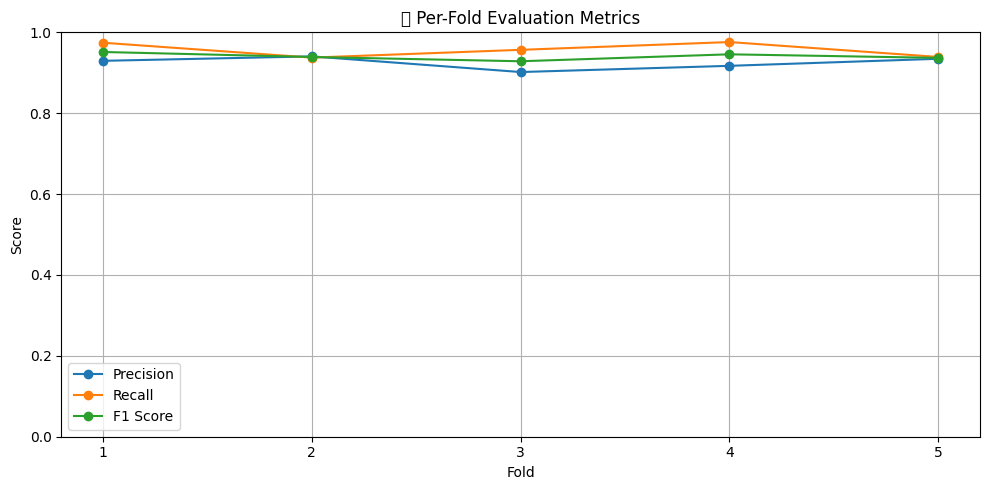

In [9]:
# Aggregate metrics
results_df = pd.DataFrame(fold_metrics)

print("\n🔚 Overall Cross-Validation Averages:")
print(results_df.describe().loc[['mean']])

print("\n📊 Overall Classification Report (All Folds Combined):")
print(classification_report(all_trues, all_preds, target_names=["NFR", "F"]))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(results_df["fold"], results_df["precision"], label="Precision", marker='o')
plt.plot(results_df["fold"], results_df["recall"], label="Recall", marker='o')
plt.plot(results_df["fold"], results_df["f1"], label="F1 Score", marker='o')
plt.xticks(results_df["fold"])
plt.title("📈 Per-Fold Evaluation Metrics")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
pd.set_option("display.max_colwidth", None)  # show full text in DataFrame


# ==============================
# 🟢 FINAL MODEL TRAINING ON FULL DATA
# ==============================
print("\n🟢 Training final model on full dataset for SHAP explanations...")

full_dataset = RequirementsDataset(df['RequirementText'], df['label'])
full_loader = DataLoader(full_dataset, batch_size=config["batch_size"], shuffle=True, num_workers=2, pin_memory=True)

final_model = BERT_BiLSTM_Attention().to(config["device"])
optimizer = AdamW(final_model.parameters(), lr=config["learning_rate"])
criterion = nn.BCEWithLogitsLoss()

for epoch in range(config["epochs"]):
    train_loss = train_fn(final_model, full_loader, optimizer, criterion, scaler, config, fold=-1, epoch=epoch)
    print(f"Final Training Epoch {epoch+1}/{config['epochs']} | Loss: {train_loss:.4f}")

# ==============================
# 🔍 SHAP Explainability on Final Model
# ==============================
try:
    final_model.eval()

    def predict(texts):
        enc = tokenizer(list(texts), truncation=True, padding=True,
                        max_length=config["max_length"], return_tensors="pt")
        enc = {k: v.to(config["device"]) for k, v in enc.items()}
        with torch.no_grad():
            outputs = final_model(enc["input_ids"], enc["attention_mask"])
            return torch.sigmoid(outputs).cpu().numpy()

    # Background & explainer
    background = df['RequirementText'].sample(20, random_state=42).tolist()
    masker = shap.maskers.Text(tokenizer)
    explainer = shap.Explainer(predict, masker, algorithm="partition")

    # Pick test samples
    sample_df = df.sample(10, random_state=0)   # more examples since it's the final run
    test_samples = sample_df["RequirementText"].tolist()
    true_labels = sample_df["label"].tolist()

    # Run SHAP
    shap_values = explainer(test_samples)

    # Collect results into table
    table_rows = []
    preds = (predict(test_samples) > 0.5).astype(int).flatten()

    for i, text in enumerate(test_samples):
        token_scores = list(zip(shap_values.data[i], shap_values.values[i]))
        token_scores_sorted = sorted(token_scores, key=lambda x: abs(x[1]), reverse=True)

        positive_tokens = [tok for tok, score in token_scores_sorted if score > 0][:5]
        negative_tokens = [tok for tok, score in token_scores_sorted if score < 0][:5]

        if preds[i] == 1:  # Functional
            rationale = (
                f"Predicted **Functional** due to terms like {', '.join(positive_tokens)} "
                f"that describe concrete actions or measurable constraints."
            )
            if negative_tokens:
                rationale += f" Less weight was given to terms like {', '.join(negative_tokens)}."
        else:  # Non-Functional
            rationale = (
                f"Predicted **Non-Functional** due to quality-related terms like {', '.join(positive_tokens)}, "
                f"highlighting performance/attributes instead of actions."
            )
            if negative_tokens:
                rationale += f" Words like {', '.join(negative_tokens)} were down-weighted."

        table_rows.append({
            "Requirement": text,
            "Actual Class": "Functional" if true_labels[i] == 1 else "Non-Functional",
            "Predicted Class": "Functional" if preds[i] == 1 else "Non-Functional",
            "Explanation": rationale
        })

    shap_table = pd.DataFrame(table_rows)
    display(shap_table)
    shap_table.to_csv("shap_explanations_final.csv", index=False)

except Exception as e:
    print(f"⚠️ SHAP failed on final model: {e}")


🟢 Training final model on full dataset for SHAP explanations...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🟡 Fold 0 | Epoch 1 [Train]:   0%|          | 0/65 [00:00<?, ?it/s]

Final Training Epoch 1/15 | Loss: 0.4471


🟡 Fold 0 | Epoch 2 [Train]:   0%|          | 0/65 [00:00<?, ?it/s]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 10/10 [03:54<00:00, 10.06s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 11it [04:00, 24.09s/it]                        


,Requirement,Actual Class,Predicted Class,Explanation
0,"The Center shall provide the following link information: link identifier, link name, road number, link type, link type description, start node (see below for node information), end node (see below for node information), direction, length, capacity, speed limit, speed limit truck, number of lanes.",Functional,Functional,"Predicted **Functional** due to terms like Ġfollowing, Ġtruck, Ġcapacity, ., Ġtype that describe concrete actions or measurable constraints. Less weight was given to terms like Ġlanes, Ġof, Ġnumber, ,, Ġlimit."
1,No year designation used in any requirement,Functional,Functional,"Predicted **Functional** due to terms like Ġdesignation, Ġyear, Ġrequirement, , Ġin that describe concrete actions or measurable constraints. Less weight was given to terms like No, Ġused, Ġany, ."
2,NPAC SMS shall if the old and new service provider timer types match set the subscription version timer type to that timer type.,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like Ġversion, Ġtypes, Ġtype, AC, Ġthe, highlighting performance/attributes instead of actions. Words like Ġshall, Ġif, Ġsubscription, Ġold, Ġtimer were down-weighted."
3,Correction operation to capture and deliver a formatted correction request for transmission by a vessel’s communications system(s) to the UK fisheries administrations’ ERS system to correct previously send data (COR).,Functional,Functional,"Predicted **Functional** due to terms like Correction, Ġdeliver, Ġtransmission, Ġfisheries, Ġformatted that describe concrete actions or measurable constraints. Less weight was given to terms like Ġand, Ġa, ĠE, Ġcapture, Ġadministrations."
4,The system is configurable to e-mail warnings about multiple failed login attempts from the same user.,Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like Ġ, Ġ, Ġabout, Ġsystem, mail, highlighting performance/attributes instead of actions. Words like Ġlogin, Ġattempts, Ġuser, Ġfrom, Ġwarnings were down-weighted."
5,"NPAC SMS shall update the Block Failed SP List upon completion of the Activation broadcast, and a response from ALL EDR and non-EDR Local SMSs, or retries are exhausted, as defined in RR3-138.1, and RR3-138.2. (Previously B-275)",Functional,Functional,"Predicted **Functional** due to terms like 1, Ġupdate, ,, Ġcompletion, ĠFailed that describe concrete actions or measurable constraints. Less weight was given to terms like Ġand, ĠB, ĠRR, ., Ġ(."
6,NPAC SMS shall provide NPAC SMS personnel with the functionality to re-send modify active Subscription Version requests to all failed Local SMSs.,Functional,Functional,"Predicted **Functional** due to terms like send, ., Ġrequests, s, - that describe concrete actions or measurable constraints. Less weight was given to terms like Ġactive, ĠSub, ĠLocal, Ġfailed, ĠVersion."
7,Customer‟s sales history must be synchronized to QuickBooks POS and roll up in a similar fashion as donation statistics.,Functional,Functional,"Predicted **Functional** due to terms like Ġsimilar, Ġsynchronized, âĢ, Customer, Ġstatistics that describe concrete actions or measurable constraints. Less weight was given to terms like Ł, s, Ġas, Ġup, Ġsales."
8,"The Center shall support the following status information about each Railroad Crossing: Network identifier (owner of railroad Crossing), Link Identifier, Rail Crossing Identifier, Rail Crossing Name, Location (latitude/longitude), Status, Rail Type, Estimated Time for Train to Clear of Intersection, Estimated Minutes to Train Arrival, Rail closing signal type.",Non-Functional,Non-Functional,"Predicted **Non-Functional** due to quality-related terms like ĠCenter, ĠRail, Ġshall, ,, itude, highlighting performance/attributes instead of actions. Words like ĠCrossing, ĠCrossing, ifier, Ġrailroad, : were down-weighted."
9,NPAC SMS shall default the SOA NPA-NXX-X Indicator to FALSE. (Previously NC-3),Functional,Function